# 8. Is there a difference in the number of double faults based on gender? 

### It imports two libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Only matches with score_ready=True are retained

In [2]:
IN_DIR = "cleaned_data"

event = pd.read_parquet(f"{IN_DIR}/event.parquet")
ev_ok = event.loc[event["score_ready"]].copy()
print(f"Matches passing quality gate: {len(ev_ok)} / {len(event)}")

Matches passing quality gate: 14413 / 16873


#### It reads the match statistics file and the gender information for home and away players; the 'gender' column in each is renamed to 'home_gender' and 'away_gender' so they can be distinguished after the merge

In [3]:
stats_df = pd.read_parquet(f"{IN_DIR}/statistics.parquet")
home_g = pd.read_parquet(f"{IN_DIR}/home_team.parquet")[["match_id", "gender"]].rename(columns={"gender": "home_gender"})
away_g = pd.read_parquet(f"{IN_DIR}/away_team.parquet")[["match_id", "gender"]].rename(columns={"gender": "away_gender"})

#### It isolates only the `double_faults` rows at the match level from the statistics table

In [4]:
df_dblf = stats_df[(stats_df["statistic_name"] == "double_faults") & (stats_df["period"] == "ALL")][["match_id", "home_value", "away_value"]]

#### Using successive inner joins, the `double_faults` table is first restricted to valid matches (`ev_ok`), and then the gender of both players is added to it

In [5]:
merged = (
    ev_ok[["match_id"]]
    .merge(df_dblf, on="match_id", how="inner")
    .merge(home_g, on="match_id", how="inner")
    .merge(away_g, on="match_id", how="inner")
)

#### It creates two separate dataframes for home and away players (each with identical `double_faults` and `gender` columns)
#### stacks them vertically to establish a "player-per-match" unit of analysis, and removes rows where gender is unspecified

In [6]:
home_long = merged[["home_value", "home_gender"]].rename(columns={"home_value": "double_faults", "home_gender": "gender"})
away_long = merged[["away_value", "away_gender"]].rename(columns={"away_value": "double_faults", "away_gender": "gender"})
long_df = pd.concat([home_long, away_long], ignore_index=True).dropna(subset=["gender"])

#### It separates the `double_faults` values ​​for women (F) and men (M) and prints the mean/median for each

In [7]:
F = long_df.loc[long_df.gender == "F", "double_faults"]
M = long_df.loc[long_df.gender == "M", "double_faults"]
print(f"Mean F={F.mean():.2f}, Mean M={M.mean():.2f}")
print(f"Median F={F.median():.2f}, Median M={M.median():.2f}")

Mean F=3.49, Mean M=2.66
Median F=3.00, Median M=2.00


#### It plots box plots for two groups: the box for women in pink (#FBA0E3) and the box for men in dark blue (#1F5973)
#### `showfliers=False` excludes outliers from the display (though not from the calculation). The exact mean value for each group is displayed next to the corresponding box using `ax.text`

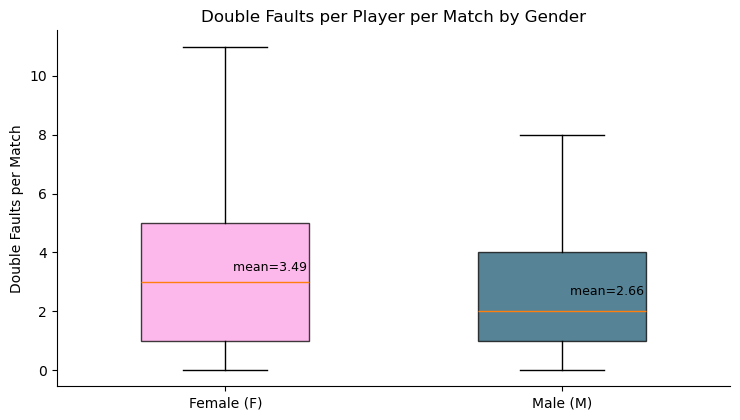

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
bp = ax.boxplot([F, M], tick_labels=["Female (F)", "Male (M)"], patch_artist=True, showfliers=False, widths=0.5)
for patch, c in zip(bp["boxes"], ["#FBA0E3", "#1F5973"]):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
ax.set_title("Double Faults per Player per Match by Gender")
ax.set_ylabel("Double Faults per Match")
ax.text(1, F.mean(), f"  mean={F.mean():.2f}", va="center", fontsize=9)
ax.text(2, M.mean(), f"  mean={M.mean():.2f}", va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("charts/q8_double_faults.png", dpi=170)
plt.show()

The mean number of double faults for female players is 3.49, which is noticeably higher than the 2.66 recorded for men; the median values—3 versus 2—reflect this same pattern.

Observing the pink box plot (representing women), one can see a larger interquartile range, indicating greater dispersion in the number of double faults among female players.

Given the large sample size, the results are reliable; thus, it can be concluded that women commit significantly more double faults than men.

(Outliers have been excluded from the plot to improve readability.)